Aprendizaje por reforzamiento usando Q-Learning (uso del dataset: df_ruido)

In [ ]:
import pandas as pd

# Ruta del archivo en tu Drive
ruta_excel = '.../data/data_proceseed/df_ruido.xlsx'

# Leer el archivo Excel
df_ruido = pd.read_excel(ruta_excel)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

df_imputado = df_ruido.copy()

# === 1. Definir columnas de estado
cols_estado = [
    'Semana',
    'O2_am', 'pH_am', 'T_am',
    'ph', 'humedad', 'proteina_dumas', 'fibra','fosfolipidos', 'grasa', 'tyr',
    'FCAsem','FCAacu','GPsem', 'GPacu','CAsem', 'CAacum',
     'IC',
    'AlimentoReal_kg_', 'Biomasa_kg_',
    'PesoInicial','Pesodemuestreo_g_','sobrevivencia_limpia',
    'TA_porcentaje_','TC_porcentaje_',
    'ConsumoAlimento_g_cam_dia_',
    'ROI'
]


# === 2. Cargar esas columnas + acción + recompensa
df_rl = df_imputado[cols_estado + ['TA_porcentaje_', 'ROI']].copy()

# === 3. Discretizar estados
est = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
df_rl[cols_estado] = est.fit_transform(df_rl[cols_estado])

# === 4. Convertir columnas discretizadas a enteros
df_rl[cols_estado] = df_rl[cols_estado].astype(int)

# === 5. Generar representación del estado como string
states = df_rl[cols_estado].astype(str).agg('_'.join, axis=1)

# === 6. Definir acciones (tasa alimentación)
df_rl['TA_redondeado'] = df_rl['TA_porcentaje_'].round(1)
actions = sorted(df_rl['TA_redondeado'].unique())

# === 7. Crear Q-table vacía con float
q_table = pd.DataFrame(0.0, index=states.unique(), columns=actions)

# === 8. Parámetros
alpha = 0.1
gamma = 0.9

# === 9. Entrenamiento Q-learning
for idx in range(len(df_rl) - 1):
    s = states.iloc[idx]
    a = df_rl['TA_redondeado'].iloc[idx]
    r = df_rl['ROI'].iloc[idx]  # Puedes cambiar a 'IC' si quieres otra recompensa
    s_next = states.iloc[idx + 1]

    if s_next not in q_table.index:
        q_table.loc[s_next] = [0.0] * len(actions)

    q_table.loc[s, a] = float(q_table.loc[s, a] + alpha * (r + gamma * q_table.loc[s_next].max() - q_table.loc[s, a]))

# === 10. Resultado
q_table_final = q_table.round(3)
q_table_final.head(10)



Implementación QLearning

In [ ]:
#preparando el entorno
import numpy as np
import pandas as pd
from collections import defaultdict
import random

df = df_ruido.copy()

# === Discretización de estado ===
df['Semana'] = df['Semana'].astype(int)
df['T_am_bin'] = pd.cut(df['T_am'], bins=[19, 24, 28, 34], labels=[0, 1, 2]).astype(float)
df['O2_am_bin'] = pd.cut(df['O2_am'], bins=[0, 3, 5, 9], labels=[0, 1, 2]).astype(float)
df['pH_am_bin'] = pd.cut(df['pH_am'], bins=[6.5, 7.5, 8.2, 9], labels=[0, 1, 2]).astype(float)
df['ph_bin'] = pd.qcut(df['ph'], q=3, labels=[0, 1, 2]).astype(float)
df['humedad_bin'] = pd.qcut(df['humedad'], q=3, labels=[0, 1, 2]).astype(float)
df['proteina_bin'] = pd.qcut(df['proteina_dumas'], q=3, labels=[0, 1, 2]).astype(float)
df['fibra_bin'] = pd.qcut(df['fibra'], q=3, labels=[0, 1, 2]).astype(float)
df['fosfolipidos_bin'] = pd.qcut(df['fosfolipidos'], q=3, labels=[0, 1, 2]).astype(float)
df['grasa_bin'] = pd.qcut(df['grasa'], q=3, labels=[0, 1, 2]).astype(float)
df['tyr_bin'] = pd.qcut(df['tyr'], q=3, labels=[0, 1, 2]).astype(float)


# === Discretización de acción ===
df['TA_bin'] = pd.cut(df['TA_porcentaje_'], bins=[0, 30, 60, 100], labels=[0, 1, 2]).astype(float)
df['TC_bin'] = pd.cut(df['TC_porcentaje_'], bins=[0, 30, 60, 100], labels=[0, 1, 2]).astype(float)
df['Alimento_bin'] = pd.qcut(df['AlimentoReal_kg_'], q=3, labels=[0, 1, 2]).astype(float)



###Paso 2:Definir estados, acciones y recompensas
# Supón que ya tienes estos discretizados como enteros
states = df[[
    'Semana', 'T_am_bin', 'O2_am_bin', 'pH_am_bin',
    'ph_bin', 'humedad_bin', 'proteina_bin', 'fibra_bin',
    'fosfolipidos_bin', 'grasa_bin', 'tyr_bin'
]].apply(tuple, axis=1).unique()


actions = df[['TA_bin', 'TC_bin', 'Alimento_bin']].apply(tuple, axis=1).unique()

# Crear un diccionario de recompensas: Estado -> Acción -> Recompensa
reward_table = defaultdict(lambda: defaultdict(float))

for _, row in df.iterrows():
    estado = (row['Semana'], row['T_am'], row['O2_am'], row['pH_am'])
    accion = (row['TA_bin'], row['TC_bin'], row['Alimento_bin'])

    ic = row['IC'] if not np.isnan(row['IC']) else 0
    roi = row['ROI'] if not np.isnan(row['ROI']) else 0
    sobrev = row['sobrevivencia_limpia'] if not np.isnan(row['sobrevivencia_limpia']) else 0

    recompensa = 0.4 * roi + 0.3 * ic + 0.3 * (sobrev / 100)  # normalizado
    reward_table[estado][accion] = recompensa


###Paso 3: Q-learning
Q = defaultdict(lambda: defaultdict(float))
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 10000

state_list = list(states)
action_list = list(actions)

for ep in range(episodes):
    estado = random.choice(state_list)

    for _ in range(10):
        if np.random.rand() < epsilon:
            accion = random.choice(action_list)
        else:
            accion = max(Q[estado], key=Q[estado].get, default=random.choice(action_list))

        recompensa = reward_table[estado][accion]
        proximo_estado = estado  # sin transición (modelo basado en política estática)

        max_q_next = max(Q[proximo_estado].values(), default=0)
        Q[estado][accion] += alpha * (recompensa + gamma * max_q_next - Q[estado][accion])


###Paso 4: Política final
policy = {estado: max(Q[estado], key=Q[estado].get) for estado in Q}
policy_df = pd.DataFrame([
    {'Estado': estado, 'TA_bin': a[0], 'TC_bin': a[1], 'Alimento_bin': a[2]}
    for estado, a in policy.items()
])

import json
import pandas as pd

ruta_base = ".../outputs/q_learning/"

# ✅ Convertimos Q a formato serializable: clave → str, valor → dict con claves str
Q_serializable = {
    str(state): {str(action): float(value) for action, value in actions.items()}
    for state, actions in Q.items()
}

# ✅ Guardamos Q como JSON
with open(f"{ruta_base}/q_table_optima.json", "w") as f:
    json.dump(Q_serializable, f)

# ✅ Convertimos policy a CSV-friendly
policy_df = pd.DataFrame([
    {
        'Estado': str(state),
        'TA_bin': int(action[0]),
        'TC_bin': int(action[1]),
        'Alimento_bin': int(action[2])
    }
    for state, action in policy.items()
])

# ✅ Guardamos la política como CSV
policy_df.to_csv(f"{ruta_base}/policy_optima.csv", index=False)

print("✅ Política y Q_table guardadas correctamente como JSON y CSV.")



Política Q-Learning legible

In [ ]:
import numpy as np
import pandas as pd

# Cargar el archivo df_ruido.xlsx
file_path = "../data/data_processed/df_ruido.xlsx"
df_ruido = pd.read_excel(file_path)

# Variables de interés para reconstruir rangos reales
variables_interes = [
    'fibra', 'fosfolipidos',  'grasa', 'humedad', 'proteina_dumas','tyr',
     'O2_am', 'T_am', 'pH_am','ph',
    'TA_porcentaje_','TC_porcentaje_'
]

# Calcular el rango real de cada variable en df_ruido
rangos_reales = df_ruido[variables_interes].agg(['min', 'max'])

# Simulación de df_q: tabla óptima con variables discretizadas
# Para esta demo, discretizamos df_ruido por bins=10 como ejemplo
df_q = df_ruido.copy()
bins = 10
for col in variables_interes:
    df_q[col] = pd.qcut(df_q[col], q=bins, labels=False, duplicates='drop')

# Agrupar para obtener combinaciones únicas y calcular medias
df_rangos = df_q.groupby(variables_interes).agg({'IC': 'mean', 'ROI': 'mean', 'Semana': 'mean', 'sobrevivencia_limpia': 'mean'}).reset_index()

# Asociar cada valor discreto a su rango real
df_rangos_rangos = pd.DataFrame()
for col in variables_interes:
    min_val = rangos_reales.loc['min', col]
    max_val = rangos_reales.loc['max', col]
    bin_size = (max_val - min_val) / bins

    df_rangos_rangos[f'{col}_min_real'] = df_rangos[col].apply(lambda x: round(min_val + x * bin_size, 3))
    df_rangos_rangos[f'{col}_max_real'] = df_rangos[col].apply(lambda x: round(min_val + (x + 1) * bin_size, 3))

# Combinar con los valores originales
df_resultado = pd.concat([df_rangos, df_rangos_rangos], axis=1)


# Guardar CSV final con etiquetas traducidas
ruta_final = "/outputs/q_learning/policy_optima_traducida.csv"
df_resultado.to_csv(ruta_final, index=False)

ruta_final
df_resultado.head()


,fibra,fosfolipidos,grasa,humedad,proteina_dumas,tyr,O2_am,T_am,pH_am,ph,...,T_am_min_real,T_am_max_real,pH_am_min_real,pH_am_max_real,ph_min_real,ph_max_real,TA_porcentaje__min_real,TA_porcentaje__max_real,TC_porcentaje__min_real,TC_porcentaje__max_real
0,0,0,4,9,8,8,7,0,2,5,...,23.70,24.68,7.538,7.682,7.272,7.564,0.94,1.01,0.87,0.923
1,0,0,5,9,6,8,4,6,9,5,...,29.58,30.56,8.546,8.690,7.272,7.564,0.94,1.01,0.87,0.923
2,0,0,5,9,6,8,8,0,3,4,...,23.70,24.68,7.682,7.826,6.981,7.272,0.94,1.01,0.87,0.923
3,0,0,5,9,7,8,1,4,0,4,...,27.62,28.60,7.250,7.394,6.981,7.272,1.01,1.08,0.87,0.923
4,0,0,5,9,7,8,2,4,0,4,...,27.62,28.60,7.250,7.394,6.981,7.272,0.94,1.01,0.87,0.923


politica legible df_policy


In [ ]:
import pandas as pd
import numpy as np

# Ruta
ruta_policy = "outputs/q_learning/policy_optima.csv"
df_policy = pd.read_csv(ruta_policy)

# Descomponer 'Estado' en columnas individuales
estado_cols = ['Semana', 'T_am_bin', 'O2_am_bin', 'pH_am_bin', 'ph_bin',
               'humedad_bin', 'proteina_bin', 'fibra_bin', 'fosfolipidos_bin',
               'grasa_bin', 'tyr_bin']

df_policy[estado_cols] = df_policy['Estado'].str.strip('()') \
    .str.split(',', expand=True) \
    .apply(lambda col: col.str.strip()).astype(float).astype(int)

# Cargar df_ruido original para obtener los rangos reales
df_ruido = pd.read_excel(".../data/data_processed/df_ruido.xlsx")

# Variables numéricas discretizadas
variables_discretizadas = {
    'T_am_bin': 'T_am',
    'O2_am_bin': 'O2_am',
    'pH_am_bin': 'pH_am',
    'ph_bin': 'ph',
    'humedad_bin': 'humedad',
    'proteina_bin': 'proteina_dumas',
    'fibra_bin': 'fibra',
    'fosfolipidos_bin': 'fosfolipidos',
    'grasa_bin': 'grasa',
    'tyr_bin': 'tyr'
}

# Calcular los rangos reales para cada bin
bin_labels = [0, 1, 2]
bin_ranges = {}

for bin_col, real_col in variables_discretizadas.items():
    bins = pd.qcut(df_ruido[real_col], q=3, labels=bin_labels, duplicates='drop', retbins=True)[1]
    bin_ranges[bin_col] = [(round(bins[i], 2), round(bins[i+1], 2)) for i in range(len(bins)-1)]

# Función para convertir valor a rango string
def valor_a_rango(val, var):
    r_min, r_max = bin_ranges[var][val]
    return f"[{r_min}; {r_max})"  # 👉 Separador cambiado a punto y coma

# Aplicar traducción
for var in variables_discretizadas.keys():
    df_policy[f'{var}_rango'] = df_policy[var].apply(lambda x: valor_a_rango(x, var))

# Mantener solo columnas deseadas
cols_finales = ['Semana', 'TA_bin', 'TC_bin', 'Alimento_bin'] + [f'{var}_rango' for var in variables_discretizadas.keys()]
df_rangos_policy = df_policy[cols_finales]

# Guardar con separador ;
#ruta_salida = "/content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/policy_optima_con_rangos.csv"
#df_rangos_policy.to_csv(ruta_salida, index=False, sep=";")
#print("✅ Política con rangos guardada con separador ';' en:", ruta_salida)

# === Agregar rangos para las acciones ===

# Definir los bins usados para discretización original
bins_ta_tc = [0, 30, 60, 100]
bins_alimento = pd.qcut(df_ruido['AlimentoReal_kg_'], q=3, retbins=True, duplicates='drop')[1]

# Funciones de traducción
def traducir_bin_ta_tc(val):
    val = int(val)
    return f"[{bins_ta_tc[val]}; {bins_ta_tc[val+1]})"

def traducir_bin_alimento(val):
    val = int(val)
    return f"[{round(bins_alimento[val], 2)}; {round(bins_alimento[val+1], 2)})"

# Agregar columnas traducidas
df_rangos_policy['TA_bin_rango'] = df_rangos_policy['TA_bin'].astype(float).astype(int).apply(traducir_bin_ta_tc)
df_rangos_policy['TC_bin_rango'] = df_rangos_policy['TC_bin'].astype(float).astype(int).apply(traducir_bin_ta_tc)
df_rangos_policy['Alimento_bin_rango'] = df_rangos_policy['Alimento_bin'].astype(float).astype(int).apply(traducir_bin_alimento)


# Reordenar columnas para exportar con rangos
cols_finales_completas = ['Semana', 'TA_bin_rango', 'TC_bin_rango', 'Alimento_bin_rango'] + \
                         [f'{var}_rango' for var in variables_discretizadas.keys()]

# Guardar con separador ;
ruta_salida_final = ".../outputs/q_learning/policy_completa_con_rangos.csv"
df_rangos_policy[cols_finales_completas].to_csv(ruta_salida_final, index=False, sep=";")

print("✅ Política final con todos los rangos (acciones y estado) guardada en:", ruta_salida_final)




✅ Política final con todos los rangos (acciones y estado) guardada en: /content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/policy_completa_con_rangos.csv


/tmp/ipython-input-167-553334715.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rangos_policy['TA_bin_rango'] = df_rangos_policy['TA_bin'].astype(float).astype(int).apply(traducir_bin_ta_tc)
/tmp/ipython-input-167-553334715.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rangos_policy['TC_bin_rango'] = df_rangos_policy['TC_bin'].astype(float).astype(int).apply(traducir_bin_ta_tc)
/tmp/ipython-input-167-553334715.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

Ejecutar Streamlit desde Colab con workaround (no recomendado para producción)

In [ ]:
!ngrok config add-authtoken #"colocar el token"


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!python "/data/app/simulador.py"


2025-07-24 06:40:05.760 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 06:40:05.817 
  command:

    streamlit run /content/drive/MyDrive/UNI/tercer ciclo/2.Proyecto_investigacion/Clase_13/simulador.py [ARGUMENTS]
2025-07-24 06:40:05.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 06:40:05.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 06:40:05.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 06:40:05.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 06:40:05.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 06:40:05.817 T

In [ ]:
# Paso 1: Instalar si no está instalado
!pip install streamlit pyngrok --quiet

# Paso 2: Importar y abrir túnel NGROK en el puerto 8501
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(f"🌐 Tu app estará disponible en: {public_url}")

# Paso 3: Ejecutar Streamlit (en segundo plano)
!streamlit run '/data/in_production/simulador.py' &


🌐 Tu app estará disponible en: NgrokTunnel: "https://5daf828aa0b6.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.58.83:8501

────────────────────────── Traceback (most recent call last) ───────────────────────────
  /usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py:3805 in get_loc   
                                                                                        
    3802 │   │   """                                                                    
    3803 │   │   casted_key = self._maybe_cast_indexer(key)                             
    3804 │   │   try:                                                                   
  ❱ 3805 │   │   │   return self._engine.get_loc(casted_key)                            
    3806 │   │   except KeyError as err:                                                
    3

Intento Q_Learning por semana


In [ ]:
import numpy as np
import pandas as pd
import random

df = df_ruido.copy()

# === Discretización de estado ===
df['Semana'] = df['Semana'].astype(float)
df['T_am_bin'] = pd.cut(df['T_am'], bins=[19, 24, 28, 34], labels=[0, 1, 2]).astype(float)
df['O2_am_bin'] = pd.cut(df['O2_am'], bins=[0, 3, 5, 9], labels=[0, 1, 2]).astype(float)
df['pH_am_bin'] = pd.cut(df['pH_am'], bins=[6.5, 7.5, 8.2, 9], labels=[0, 1, 2]).astype(float)

df['state'] = df.apply(lambda row: str((
    float(row['Semana']),
    float(row['T_am_bin']),
    float(row['O2_am_bin']),
    float(row['pH_am_bin'])
)), axis=1)

# === Discretización de acción ===
df['TA_bin'] = pd.cut(df['TA_porcentaje_'], bins=[0, 30, 60, 100], labels=[0, 1, 2]).astype(float)
df['TC_bin'] = pd.cut(df['TC_porcentaje_'], bins=[0, 30, 60, 100], labels=[0, 1, 2]).astype(float)
df['Alimento_bin'] = pd.qcut(df['AlimentoReal_kg_'], q=3, labels=[0, 1, 2]).astype(float)

df['action'] = df.apply(lambda row: str((
    float(row['TA_bin']),
    float(row['TC_bin']),
    float(row['Alimento_bin'])
)), axis=1)

# === Recompensa ===
df['IC_norm'] = (df['IC'] - df['IC'].min()) / (df['IC'].max() - df['IC'].min())
df['ROI_norm'] = (df['ROI'] - df['ROI'].min()) / (df['ROI'].max() - df['ROI'].min())
df['surv_norm'] = df['sobrevivencia_limpia'] / 100
df['FCA_norm'] = (df['FCAsem'] - df['FCAsem'].min()) / (df['FCAsem'].max() - df['FCAsem'].min())

df['reward'] = (
    4 * df['ROI_norm'] +
    4 * df['IC_norm'] +
    3 * df['surv_norm'] -
    2 * df['FCA_norm']
)

# === Q-table como DataFrame con strings ===
states = df['state'].dropna().unique().tolist()
actions = df['action'].dropna().unique().tolist()
Q_table = pd.DataFrame(0.0, index=states, columns=actions)

# === Q-learning ===
alpha = 0.1
gamma = 0.95
epsilon = max(0.1, 0.4 * (0.995 ** ep))  # empieza en 0.4 y baja lentamente a 0.1
episodes = 20000

for ep in range(episodes):
    row = df.sample(1).iloc[0]
    s = row['state']
    a = row['action']
    r = row['reward']

    if pd.isna(s) or pd.isna(a): continue
    if s in Q_table.index and a in Q_table.columns:
        current_q = Q_table.loc[s, a]
        max_future_q = Q_table.loc[s].max()
        Q_table.loc[s, a] = current_q + alpha * (r + gamma * max_future_q - current_q)

# === Política aprendida ===
policy = Q_table.idxmax(axis=1).reset_index()
policy.columns = ['Estado (Semana, T_am, O2_am, pH_am)', 'Mejor acción (TA, TC, AlimentoReal_bin)']
print("✅ Política aprendida (primeras filas):")
print(policy.head())




✅ Política aprendida (primeras filas):
  Estado (Semana, T_am, O2_am, pH_am) Mejor acción (TA, TC, AlimentoReal_bin)
0                (5.0, 1.0, 2.0, 1.0)                         (0.0, 0.0, 0.0)
1                (4.0, 1.0, 2.0, 1.0)                         (0.0, 0.0, 0.0)
2                (2.0, 1.0, 2.0, 1.0)                         (0.0, 0.0, 0.0)
3                (6.0, 1.0, 2.0, 1.0)                         (0.0, 0.0, 0.0)
4                (6.0, 1.0, 1.0, 1.0)                         (0.0, 0.0, 0.0)


visualizacion la politica

In [ ]:
import ast  # para convertir string -> tupla

# Convierte las cadenas a tuplas reales
policy['Estado (Semana, T_am, O2_am, pH_am)'] = policy['Estado (Semana, T_am, O2_am, pH_am)'].apply(ast.literal_eval)
policy['Mejor acción (TA, TC, AlimentoReal_bin)'] = policy['Mejor acción (TA, TC, AlimentoReal_bin)'].apply(ast.literal_eval)



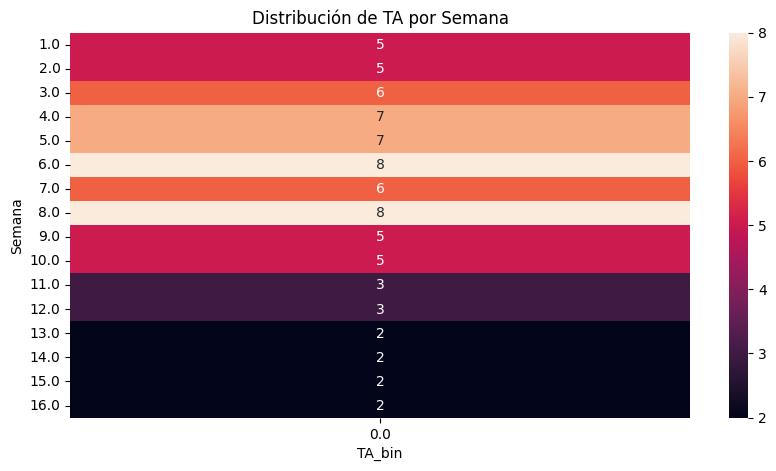

In [ ]:
policy[['Semana', 'T_am', 'O2_am', 'pH_am']] = pd.DataFrame(policy['Estado (Semana, T_am, O2_am, pH_am)'].tolist(), index=policy.index)
policy[['TA_bin', 'TC_bin', 'Alimento_bin']] = pd.DataFrame(policy['Mejor acción (TA, TC, AlimentoReal_bin)'].tolist(), index=policy.index)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.heatmap(pd.crosstab(policy['Semana'], policy['TA_bin']), annot=True, fmt='d')
plt.title("Distribución de TA por Semana")
plt.show()


Heatmap de TC_bin por semana

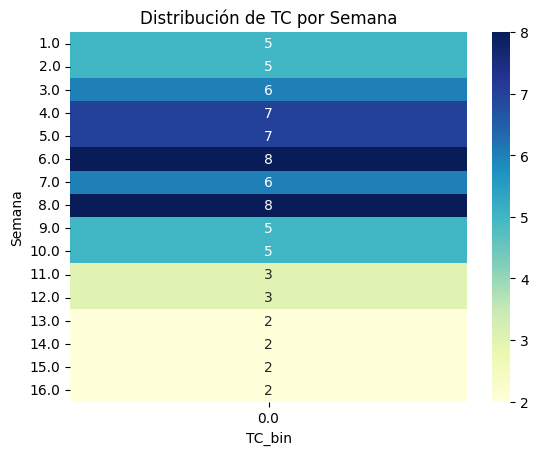

In [ ]:
# Heatmap de frecuencia de TC_bin por semana
tc_heatmap = policy.groupby(['Semana', 'TC_bin']).size().unstack(fill_value=0)
sns.heatmap(tc_heatmap, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Distribución de TC por Semana")
plt.show()


Heatmap de Alimento_bin por semana

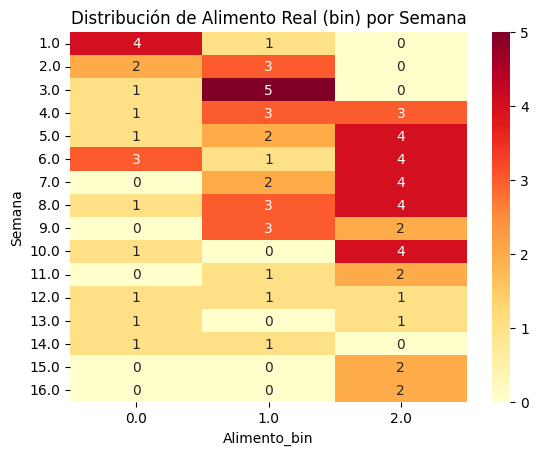

In [ ]:
# Heatmap de frecuencia de Alimento_bin por semana
alimento_heatmap = policy.groupby(['Semana', 'Alimento_bin']).size().unstack(fill_value=0)
sns.heatmap(alimento_heatmap, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Distribución de Alimento Real (bin) por Semana")
plt.show()


Convertir TA_bin, TC_bin, Alimento_bin a valores reales

In [ ]:
# Define los valores reales de cada acción binaria
ta_valores = df_ruido['TA_porcentaje_'].dropna().unique()
tc_valores = df_ruido['TC_porcentaje_'].dropna().unique()
alimento_valores = df_ruido['AlimentoReal_kg_'].dropna().unique()

# Aseguramos orden para el mapeo binario
ta_valores = sorted(ta_valores)
tc_valores = sorted(tc_valores)
alimento_valores = sorted(alimento_valores)

# Crear columnas reales en policy
policy['TA'] = policy['TA_bin'].apply(lambda x: ta_valores[int(x)])
policy['TC'] = policy['TC_bin'].apply(lambda x: tc_valores[int(x)])
policy['AlimentoReal_kg_'] = policy['Alimento_bin'].apply(lambda x: alimento_valores[int(x)])

####Unir policy con df_ruido usando condiciones
# Redondear decimales para merge
df_ruido_copy = df_ruido.copy()
df_ruido_copy['merge_key'] = list(zip(
    df_ruido_copy['Semana'].astype(float),
    df_ruido_copy['T_am'].astype(float),
    df_ruido_copy['O2_am'].astype(float),
    df_ruido_copy['pH_am'].astype(float),
    df_ruido_copy['TA_porcentaje_'].astype(float),
    df_ruido_copy['TC_porcentaje_'].astype(float),
    df_ruido_copy['AlimentoReal_kg_'].astype(float)
))

policy['merge_key'] = list(zip(
    policy['Semana'], policy['T_am'], policy['O2_am'], policy['pH_am'],
    policy['TA'], policy['TC'], policy['AlimentoReal_kg_']
))

# Hacemos merge para obtener ROI
policy = policy.merge(
    df_ruido_copy[['merge_key', 'ROI']],
    on='merge_key',
    how='left'
)


In [ ]:
# Paso 1: Redondear todas las columnas del estado y acción
def preparar_merge(df):
    return df[['Semana', 'T_am', 'O2_am', 'pH_am']].round(1).astype(float)

policy[['Semana', 'T_am', 'O2_am', 'pH_am']] = preparar_merge(policy)
df_ruido[['Semana', 'T_am', 'O2_am', 'pH_am']] = preparar_merge(df_ruido)

policy['TA'] = policy['TA'].astype(float)
policy['TC'] = policy['TC'].astype(float)
policy['AlimentoReal_kg_'] = policy['AlimentoReal_kg_'].astype(float)

df_ruido['TA_porcentaje_'] = df_ruido['TA_porcentaje_'].astype(float)
df_ruido['TC_porcentaje_'] = df_ruido['TC_porcentaje_'].astype(float)
df_ruido['AlimentoReal_kg_'] = df_ruido['AlimentoReal_kg_'].astype(float)

# Paso 2: Reconstruir la clave de unión
policy['merge_key'] = list(zip(
    policy['Semana'], policy['T_am'], policy['O2_am'], policy['pH_am'],
    policy['TA'], policy['TC'], policy['AlimentoReal_kg_']
))

df_ruido['merge_key'] = list(zip(
    df_ruido['Semana'], df_ruido['T_am'], df_ruido['O2_am'], df_ruido['pH_am'],
    df_ruido['TA_porcentaje_'], df_ruido['TC_porcentaje_'], df_ruido['AlimentoReal_kg_']
))

# Paso 3: Hacer el merge
policy = policy.drop(columns=['ROI'], errors='ignore')
policy = policy.merge(df_ruido[['merge_key', 'ROI']], on='merge_key', how='left')


In [ ]:
print(policy['ROI'].isna().sum(), "/", len(policy))  # Esperamos que no sean 76/76


76 / 76


In [ ]:
print("Ejemplo en policy:")
print(policy['merge_key'].drop_duplicates().head())

print("\nEjemplo en df_ruido:")
print(df_ruido['merge_key'].drop_duplicates().head())


Ejemplo en policy:
0    (5.0, 1.0, 2.0, 1.0, 0.8, 0.87, 0.0)
1    (4.0, 1.0, 2.0, 1.0, 0.8, 0.87, 0.0)
2    (2.0, 1.0, 2.0, 1.0, 0.8, 0.87, 0.0)
3    (6.0, 1.0, 2.0, 1.0, 0.8, 0.87, 0.0)
4    (6.0, 1.0, 1.0, 1.0, 0.8, 0.87, 0.0)
Name: merge_key, dtype: object

Ejemplo en df_ruido:
0    (5.0, 27.1, 6.1, 8.0, 1.2, 1.0, 0.004043628740...
1    (5.0, 27.1, 6.2, 8.0, 1.2, 1.0, 0.003688092314...
2    (5.0, 27.1, 6.2, 8.0, 1.2, 1.0, 0.003481994119...
3    (5.0, 27.1, 6.1, 8.0, 1.2, 1.0, 0.003984796645...
4    (5.0, 27.0, 6.1, 8.1, 1.2, 1.0, 0.003616711479...
Name: merge_key, dtype: object


In [ ]:
coinciden = set(policy['merge_key']).intersection(set(df_ruido['merge_key']))
print(f"Número de coincidencias exactas: {len(coinciden)}")


Número de coincidencias exactas: 0


Graficar ROI promedio por TA_bin

In [ ]:
print(df_ruido.columns.tolist())


['Unnamed: 0', 'O2_am', 'pH_am', 'T_am', 'ph', 'humedad', 'proteina_dumas', 'fibra', 'fosfolipidos', 'grasa', 'tyr', 'Semana', 'sobrevivencia_limpia', 'Pesodemuestreo_g_', 'PesoInicial', 'IC', 'FCAsem', 'FCAacu', 'GPsem', 'GPacu', 'CAsem', 'CAacum', 'AlimentoReal_kg_', 'Biomasa_kg_', 'TA_porcentaje_', 'TC_porcentaje_', 'ROI', 'ConsumoAlimento_g_cam_dia_', 'merge_key', 'TA_bin', 'TC_bin', 'Alimento_bin', 'Estado', 'T_am_disc', 'O2_am_disc', 'pH_am_disc']


In [ ]:
print(policy_df['Estado'].dtype)
print(df_ruido['Estado'].dtype)

print(policy_df['Estado'].head())
print(df_ruido['Estado'].head())


object
object
0    (5.0, 1.0, 2.0, 1.0)
1    (4.0, 1.0, 2.0, 1.0)
2    (2.0, 1.0, 2.0, 1.0)
3    (6.0, 1.0, 2.0, 1.0)
4    (6.0, 1.0, 1.0, 1.0)
Name: Estado, dtype: object
0    (5.0, 27.1, 6.1, 8.0)
1    (5.0, 27.1, 6.2, 8.0)
2    (5.0, 27.1, 6.2, 8.0)
3    (5.0, 27.1, 6.1, 8.0)
4    (5.0, 27.0, 6.1, 8.1)
Name: Estado, dtype: object


In [ ]:
print(policy_with_roi.columns.tolist())


['Estado (Semana, T_am, O2_am, pH_am)', 'Mejor acción (TA, TC, AlimentoReal_bin)', 'len_estado', 'Semana', 'T_am', 'O2_am', 'pH_am', 'TA_bin', 'TC_bin', 'Alimento_bin', 'TA', 'TC', 'AlimentoReal_kg_', 'merge_key', 'ROI_x', 'Estado', 'ROI_y']


In [ ]:
policy_with_roi['ROI'] = policy_with_roi['ROI_y']


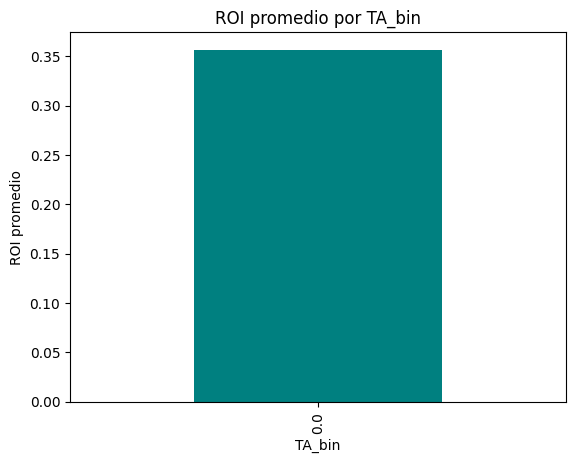

In [ ]:
policy_with_roi.groupby('TA_bin')['ROI'].mean().plot(kind='bar', color='teal')
plt.title("ROI promedio por TA_bin")
plt.xlabel("TA_bin")
plt.ylabel("ROI promedio")
plt.show()


In [ ]:
print(policy_with_roi['TA_bin'].value_counts())


TA_bin
0.0    1889
Name: count, dtype: int64


In [ ]:
print(df_ruido['TA_bin'].value_counts())


TA_bin
0    3296
1    2239
2    1786
Name: count, dtype: int64


Heatmap de Política: Estado vs. Acción

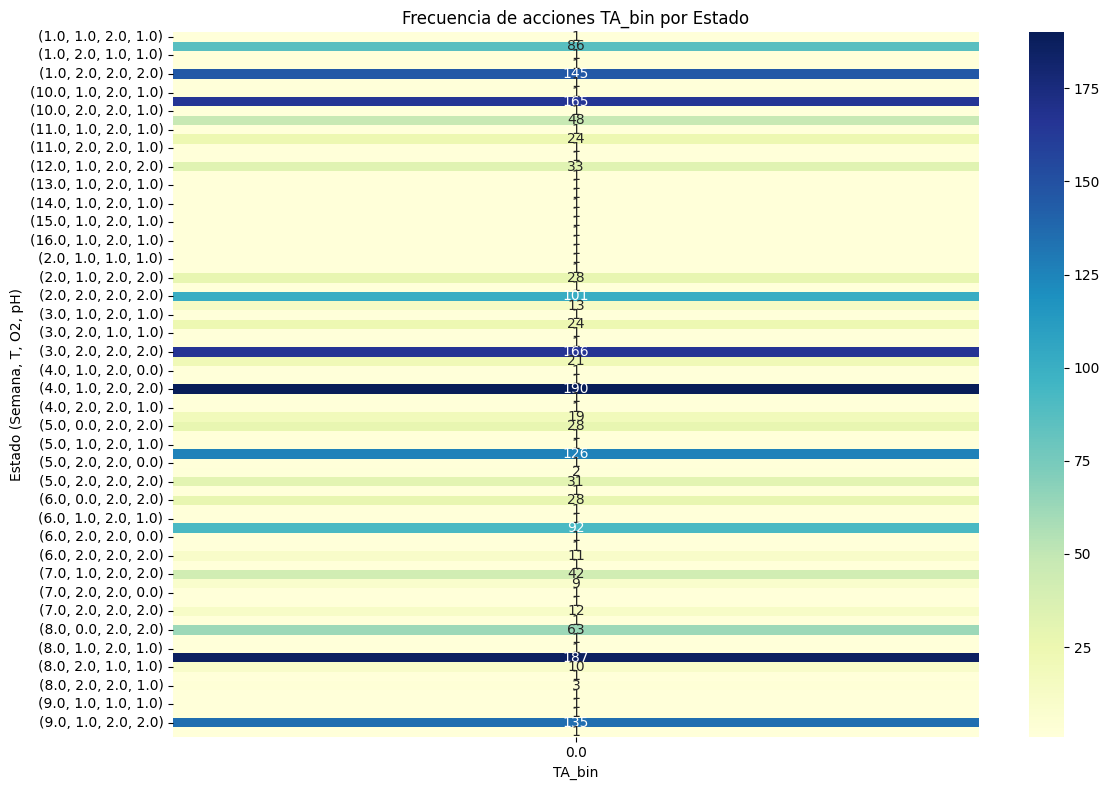

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear una representación del estado como string para agrupar
policy_with_roi["Estado_str"] = policy_with_roi["Estado"].astype(str)

# Elegimos una acción para visualizar primero: TA_bin
heatmap_data = policy_with_roi.groupby(["Estado_str", "TA_bin"]).size().unstack(fill_value=0)

# 🔥 Graficar heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Frecuencia de acciones TA_bin por Estado")
plt.ylabel("Estado (Semana, T, O2, pH)")
plt.xlabel("TA_bin")
plt.tight_layout()
plt.show()


ROI promedio por TC_bin y Alimento_bin

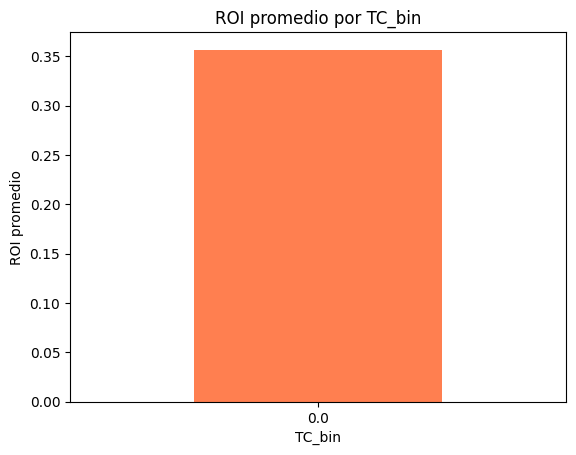

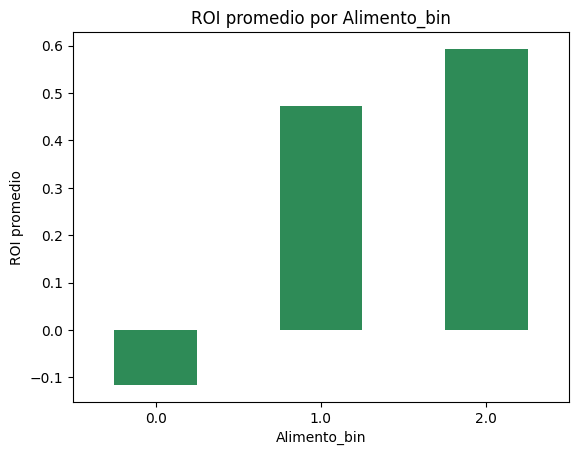

In [ ]:
# ROI promedio por TC_bin
policy_with_roi.groupby('TC_bin')['ROI_y'].mean().plot(kind='bar', color='coral')
plt.title("ROI promedio por TC_bin")
plt.xlabel("TC_bin")
plt.ylabel("ROI promedio")
plt.xticks(rotation=0)
plt.show()

# ROI promedio por Alimento_bin
policy_with_roi.groupby('Alimento_bin')['ROI_y'].mean().plot(kind='bar', color='seagreen')
plt.title("ROI promedio por Alimento_bin")
plt.xlabel("Alimento_bin")
plt.ylabel("ROI promedio")
plt.xticks(rotation=0)
plt.show()


<Axes: xlabel='TA_bin'>

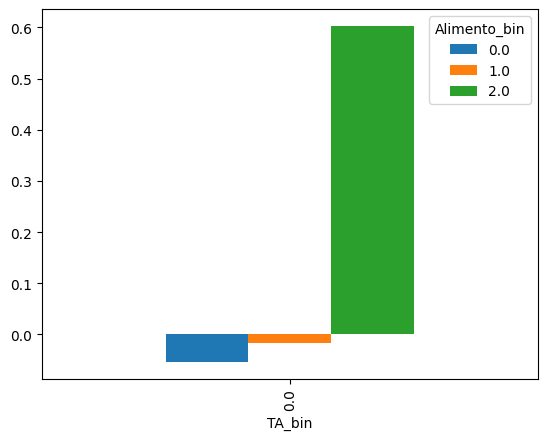

In [ ]:
df.groupby(['TA_bin', 'Alimento_bin'])['ROI'].mean().unstack().plot(kind='bar', stacked=False)
